# Comparing predicted protein abundances vs. measured values

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from collections import defaultdict


from PAModelpy.utils.pam_generation import set_up_pam

# Get the current working directory
current_directory = os.getcwd()
# If required go to repository root
if os.path.split(current_directory)[1] != 'PAM_Parametrization':
    # Go up two levels
    parent_directory = os.path.dirname(os.path.dirname(current_directory))
    # Change the directory to the parent directory
    os.chdir(parent_directory)
    
from Modules.utils.pamparametrizer_analysis import (get_results_from_simulations_fixed_mu, 
                                                    parse_enzyme_complex_id,
                                                    convert_peptide_to_enzyme_concentrations,
                                                    normalize_simulated_protein_concentrations
                                                   )
from Modules.utils.pam_generation import create_pamodel_from_diagnostics_file


Loading PAModelpy modules version 0.0.4.6
Set parameter Username

--------------------------------------------
--------------------------------------------

Academic license - for non-commercial use only - expires 2025-03-06


In [2]:
NUM_ALT_MODELS =10
PAM_KCAT_FILES = [os.path.join('Results', '3_analysis', 'parameter_files',
                                   f'proteinAllocationModel_EnzymaticData_iML1515_{file_nmbr}.xlsx') for file_nmbr in
                      range(1, NUM_ALT_MODELS+1)]
BEST_INDIV_RESULT_FILES = [os.path.join('Results','2_parametrization','diagnostics',
                                     f'pam_parametrizer_diagnostics_{i}.xlsx') for i in range(1,NUM_ALT_MODELS+1)]
ORI_PAM_KCAT_FILE = os.path.join('Results', '1_preprocessing',
                                 'proteinAllocationModel_iML1515_EnzymaticData_250219.xlsx')
ECOLI_PROTEOME_DATA_PATH = os.path.join('Data', 'Ecoli_phenotypes', 'proteome_data_extract_schmidt2016.xlsx')
ECOLI_MODEL_FILE_PATH = os.path.join('Models', 'iML1515.xml')
UNIPROT_INFO_FILE = os.path.join('Data', 'Databases', 'uniprotkb_ecolik12_240726.xlsx')

#average values from Bakken and Olsen (1984); https://pubmed.ncbi.nlm.nih.gov/16346263/
buoyant_volume = 1.09 #g_wetcell/cm^3
dryweight_per_wetweight = 0.3
DRYWEIGHT_PER_LITER = buoyant_volume*1e3*dryweight_per_wetweight #1e3 to convert cm^-3 to dm^-3

locustag_regex =r'\b([b|s]\d{4})\b'

## 1. Get the protein concentrations from the models

In [3]:
substrate_rates = [0.67, 0.5, 0.35]
pam =  set_up_pam(ORI_PAM_KCAT_FILE, ECOLI_MODEL_FILE_PATH, sensitivity=False)
enzymes = [enz.id for enz in pam.enzyme_variables if enz._model is not None]

proteomics_results={'GotEnzymes': get_results_from_simulations_fixed_mu(pamodel=pam,
                                                                           growth_rates = substrate_rates,
                                                                           proteins_to_save = enzymes,
                                                                          method_ids = ['Batch', 'mu_5', 'mu_35']
                                                                          )['proteins']}

for file, label in zip(BEST_INDIV_RESULT_FILES,
                       [f'Alternative {i}' for i in range(1,len(PAM_KCAT_FILES)+1)]
                      ):
    print('\n')
    print(label)
    model = create_pamodel_from_diagnostics_file(file,
                                          pam.copy(copy_with_pickle=True))
#     model = set_up_pam(file, ECOLI_MODEL_FILE_PATH, sensitivity=False)
    enzymes = [enz.id for enz in model.enzyme_variables if enz._model is not None]
    proteomics_results[label] = get_results_from_simulations_fixed_mu(pamodel=model,
                                                                           growth_rates = substrate_rates,
                                                                           proteins_to_save = enzymes,
                                                                          method_ids = ['Batch', 'mu_5', 'mu_35']
                                                                          )['proteins']
    

No enzyme information found for reaction: QUINDHyi
No enzyme information found for reaction: QUINDH
Setting up the proteome allocation model iML1515

Add total condition-dependent protein constraint
	Total protein concentration: 0.258 g/gDW

Add active protein sector

Add the following protein sector: TranslationalProteinSector

Add the following protein sector: UnusedEnzymeSector

Done with setting up the proteome allocation model iML1515

Running simulations with a growth rate of 0.67 1/h
The simulated growth rate is 0.055519899438461695 1/h with a substrate uptake rate of -14.999999999987928 mmol/g_cdw/h
Running simulations with a growth rate of 0.5 1/h
The simulated growth rate is 0.05551989943846203 1/h with a substrate uptake rate of -14.999999999996582 mmol/g_cdw/h
Running simulations with a growth rate of 0.35 1/h
The simulated growth rate is 0.05551989943846339 1/h with a substrate uptake rate of -14.99999999999573 mmol/g_cdw/h


Alternative 1


/home/samiralvdb/Documents/3_Projects/7_MCA_analysis/PAModelpy/src/PAModelpy/PAModel.py:1533: UserWarning: The enzyme E2 does not exist in the model. The kcat can thus not be changed.
  warnings.warn(f'The enzyme {enzyme_id} does not exist in the model. The kcat can thus not be changed.')
/home/samiralvdb/Documents/3_Projects/7_MCA_analysis/PAModelpy/src/PAModelpy/PAModel.py:1533: UserWarning: The enzyme E33 does not exist in the model. The kcat can thus not be changed.
  warnings.warn(f'The enzyme {enzyme_id} does not exist in the model. The kcat can thus not be changed.')
/home/samiralvdb/Documents/3_Projects/7_MCA_analysis/PAModelpy/src/PAModelpy/PAModel.py:1533: UserWarning: The enzyme E34 does not exist in the model. The kcat can thus not be changed.
  warnings.warn(f'The enzyme {enzyme_id} does not exist in the model. The kcat can thus not be changed.')
/home/samiralvdb/Documents/3_Projects/7_MCA_analysis/PAModelpy/src/PAModelpy/PAModel.py:1533: UserWarning: The enzyme E35 does n

Running simulations with a growth rate of 0.67 1/h
The simulated growth rate is 0.3674011823064374 1/h with a substrate uptake rate of -14.999999999989546 mmol/g_cdw/h
Running simulations with a growth rate of 0.5 1/h
The simulated growth rate is 0.3674011823064434 1/h with a substrate uptake rate of -14.999999999987725 mmol/g_cdw/h
Running simulations with a growth rate of 0.35 1/h
The simulated growth rate is 0.35 1/h with a substrate uptake rate of -8.474914252786041 mmol/g_cdw/h


Alternative 2


/home/samiralvdb/Documents/3_Projects/7_MCA_analysis/PAModelpy/src/PAModelpy/PAModel.py:1533: UserWarning: The enzyme E2 does not exist in the model. The kcat can thus not be changed.
  warnings.warn(f'The enzyme {enzyme_id} does not exist in the model. The kcat can thus not be changed.')
/home/samiralvdb/Documents/3_Projects/7_MCA_analysis/PAModelpy/src/PAModelpy/PAModel.py:1533: UserWarning: The enzyme E33 does not exist in the model. The kcat can thus not be changed.
  warnings.warn(f'The enzyme {enzyme_id} does not exist in the model. The kcat can thus not be changed.')
/home/samiralvdb/Documents/3_Projects/7_MCA_analysis/PAModelpy/src/PAModelpy/PAModel.py:1533: UserWarning: The enzyme E34 does not exist in the model. The kcat can thus not be changed.
  warnings.warn(f'The enzyme {enzyme_id} does not exist in the model. The kcat can thus not be changed.')
/home/samiralvdb/Documents/3_Projects/7_MCA_analysis/PAModelpy/src/PAModelpy/PAModel.py:1533: UserWarning: The enzyme E35 does n

Running simulations with a growth rate of 0.67 1/h
The simulated growth rate is 0.20713126456431105 1/h with a substrate uptake rate of -14.658120065593812 mmol/g_cdw/h
Running simulations with a growth rate of 0.5 1/h
The simulated growth rate is 0.20713126456431166 1/h with a substrate uptake rate of -14.658120065609593 mmol/g_cdw/h
Running simulations with a growth rate of 0.35 1/h
The simulated growth rate is 0.20713126456431052 1/h with a substrate uptake rate of -14.658120065585905 mmol/g_cdw/h


Alternative 3


...

Running simulations with a growth rate of 0.67 1/h
The simulated growth rate is 0.4236038611913334 1/h with a substrate uptake rate of -14.737423652587127 mmol/g_cdw/h
Running simulations with a growth rate of 0.5 1/h
The simulated growth rate is 0.42360386119135984 1/h with a substrate uptake rate of -14.7374236525887 mmol/g_cdw/h
Running simulations with a growth rate of 0.35 1/h
The simulated growth rate is 0.35 1/h with a substrate uptake rate of -11.937726080944653 mmol/g_cdw/h


Alternative 9


/home/samiralvdb/Documents/3_Projects/7_MCA_analysis/PAModelpy/src/PAModelpy/PAModel.py:1533: UserWarning: The enzyme E2 does not exist in the model. The kcat can thus not be changed.
  warnings.warn(f'The enzyme {enzyme_id} does not exist in the model. The kcat can thus not be changed.')
/home/samiralvdb/Documents/3_Projects/7_MCA_analysis/PAModelpy/src/PAModelpy/PAModel.py:1533: UserWarning: The enzyme E33 does not exist in the model. The kcat can thus not be changed.
  warnings.warn(f'The enzyme {enzyme_id} does not exist in the model. The kcat can thus not be changed.')
/home/samiralvdb/Documents/3_Projects/7_MCA_analysis/PAModelpy/src/PAModelpy/PAModel.py:1533: UserWarning: The enzyme E34 does not exist in the model. The kcat can thus not be changed.
  warnings.warn(f'The enzyme {enzyme_id} does not exist in the model. The kcat can thus not be changed.')
/home/samiralvdb/Documents/3_Projects/7_MCA_analysis/PAModelpy/src/PAModelpy/PAModel.py:1533: UserWarning: The enzyme E35 does n

Running simulations with a growth rate of 0.67 1/h
The simulated growth rate is 0.24975798217868062 1/h with a substrate uptake rate of -14.999999999998451 mmol/g_cdw/h
Running simulations with a growth rate of 0.5 1/h
The simulated growth rate is 0.24975798217867703 1/h with a substrate uptake rate of -14.999999999993772 mmol/g_cdw/h
Running simulations with a growth rate of 0.35 1/h
The simulated growth rate is 0.2497579821786841 1/h with a substrate uptake rate of -15.000000000002053 mmol/g_cdw/h


Alternative 10


/home/samiralvdb/Documents/3_Projects/7_MCA_analysis/PAModelpy/src/PAModelpy/PAModel.py:1533: UserWarning: The enzyme E2 does not exist in the model. The kcat can thus not be changed.
  warnings.warn(f'The enzyme {enzyme_id} does not exist in the model. The kcat can thus not be changed.')
/home/samiralvdb/Documents/3_Projects/7_MCA_analysis/PAModelpy/src/PAModelpy/PAModel.py:1533: UserWarning: The enzyme E33 does not exist in the model. The kcat can thus not be changed.
  warnings.warn(f'The enzyme {enzyme_id} does not exist in the model. The kcat can thus not be changed.')
/home/samiralvdb/Documents/3_Projects/7_MCA_analysis/PAModelpy/src/PAModelpy/PAModel.py:1533: UserWarning: The enzyme E34 does not exist in the model. The kcat can thus not be changed.
  warnings.warn(f'The enzyme {enzyme_id} does not exist in the model. The kcat can thus not be changed.')
/home/samiralvdb/Documents/3_Projects/7_MCA_analysis/PAModelpy/src/PAModelpy/PAModel.py:1533: UserWarning: The enzyme E35 does n

Running simulations with a growth rate of 0.67 1/h
The simulated growth rate is 0.4368147766959168 1/h with a substrate uptake rate of -14.99999999999951 mmol/g_cdw/h
Running simulations with a growth rate of 0.5 1/h
The simulated growth rate is 0.4368147766959166 1/h with a substrate uptake rate of -14.999999999999716 mmol/g_cdw/h
Running simulations with a growth rate of 0.35 1/h
The simulated growth rate is 0.35 1/h with a substrate uptake rate of -11.611450570013018 mmol/g_cdw/h


## 2. Import and parse the proteomics data file
From Schmidt et al (2016)

In [4]:
proteome_df = pd.read_excel(ECOLI_PROTEOME_DATA_PATH,
                            sheet_name='ProteinMasses',
                            engine='openpyxl',
                            index_col=0)
proteome_df_metadata = pd.read_excel(ECOLI_PROTEOME_DATA_PATH,
                            sheet_name='GrowthRates',
                            engine='openpyxl',
                            index_col=0)
proteome_df_cog = pd.read_excel(ECOLI_PROTEOME_DATA_PATH,
                            sheet_name='Gene2COG',
                            engine='openpyxl',
                            index_col=0)
proteome_df

,Glucose,LB,Glycerol + AA,Acetate,Fumarate,Glucosamine,Glycerol,Pyruvate,Chemostat µ=0.5,Chemostat µ=0.35,...,Stationary phase 1 day,Stationary phase 3 days,Osmotic-stress glucose,42°C glucose,pH6 glucose,Xylose,Mannose,Galactose,Succinate,Fructose
Bnumber,,,,,,,,,,,,,,,,,,,,,
b3988,0.715349,1.844515,1.159331,0.561253,0.629318,0.853642,0.732347,0.702820,1.230766,1.004203,...,4.466397e-01,4.910739e-01,0.578723,1.026062e+00,0.859739,0.934963,8.757239e-01,5.813814e-01,7.116349e-01,1.162894
b3987,0.989135,2.221614,1.299346,0.665163,0.799515,0.999545,0.936990,0.928398,1.310899,1.096833,...,5.944920e-01,5.565920e-01,0.813304,1.230390e+00,1.007687,1.109002,1.035491e+00,7.049528e-01,9.635688e-01,1.317061
b0118,1.178283,2.575086,2.722244,3.543745,3.023680,2.133445,1.674174,2.543362,2.440666,3.143073,...,1.447816e-01,1.173512e-01,0.436610,7.511055e-01,0.721180,1.038963,2.562241e+00,1.997324e+00,3.032313e+00,1.362394
b2557,0.576304,0.192554,0.548796,0.337313,0.486028,0.459618,0.485143,0.635390,0.536179,0.405983,...,1.449196e-01,1.724214e-01,0.309267,4.423852e-01,0.400793,0.403734,4.139472e-01,3.684797e-01,4.489504e-01,0.564445
b3212,0.774653,0.163742,0.176652,0.369212,0.347026,0.535762,0.597161,0.458132,0.629009,0.530940,...,6.220451e-02,4.961751e-02,0.225865,8.072853e-01,0.737951,0.676351,5.631967e-01,3.788294e-01,4.207655e-01,1.045406
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NaN,0.000167,0.001322,NaN,0.000097,0.000504,0.000339,0.000170,0.000183,0.000151,0.000068,...,1.524261e-04,0.000000e+00,0.000010,2.769145e-04,0.000304,NaN,NaN,6.570810e-05,2.050574e-04,NaN
NaN,0.000084,0.000012,0.000002,0.000249,0.000235,0.000125,0.000252,0.000419,0.000644,0.000241,...,6.333976e-07,6.237618e-07,0.000004,9.527910e-06,0.000001,0.000001,1.052190e-06,8.777261e-07,1.026332e-06,0.000001
NaN,0.002472,0.000022,0.000066,0.000770,0.000334,0.000590,0.000709,0.000805,0.000652,0.000320,...,3.374665e-07,1.943465e-04,0.000770,1.372202e-03,0.001054,0.001213,9.174705e-04,3.517107e-04,2.757719e-04,0.001285


In [5]:
#only get the chemostat cultivations on glucose
proteome_glc = proteome_df[['Glucose', 'Chemostat µ=0.5', 'Chemostat µ=0.35']] #unit: fg/cell
proteome_glc.columns = ['Batch', 'mu_5', 'mu_35']
proteome_glc

,Batch,mu_5,mu_35
Bnumber,,,
b3988,0.715349,1.230766,1.004203
b3987,0.989135,1.310899,1.096833
b0118,1.178283,2.440666,3.143073
b2557,0.576304,0.536179,0.405983
b3212,0.774653,0.629009,0.530940
...,...,...,...
NaN,0.000167,0.000151,0.000068
NaN,0.000084,0.000644,0.000241
NaN,0.002472,0.000652,0.000320


In [6]:
#use information from uniprot to map the locus tag ids to protein identifiers
uniprot_info_df = pd.read_excel(UNIPROT_INFO_FILE)
# only keep those who are in the model
uniprot_in_model = uniprot_info_df.loc[[prot in proteomics_results['Alternative 1'].enzyme_id.to_list() for prot in uniprot_info_df.Entry]]

#get the gene id from the gene names
uniprot_in_model['b_number'] = uniprot_in_model['Gene Names'].str.extract(locustag_regex)
uniprot_df = uniprot_in_model[['b_number', 'Entry', 'Mass']]
uniprot_df

/home/samiralvdb/Software/anaconda3/envs/PAModelpy/lib/python3.9/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/tmp/ipykernel_204358/1301370171.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  uniprot_in_model['b_number'] = uniprot_in_model['Gene Names'].str.extract(locustag_regex)


,b_number,Entry,Mass
2,b2029,P00350,51481
4,b1761,P00370,48581
5,b1109,P00393,47359
6,b3908,P00448,23097
8,b3417,P00490,90522
...,...,...,...
3796,b1400,P77181,21325
3826,b0335,P77495,69351
3843,b1453,P77610,54233
4227,b3488,P37627,61164


In [7]:
proteome_glc_mapped = pd.merge(proteome_glc, uniprot_df, how = 'right', 
                               left_on = 'Bnumber', right_on='b_number')
proteome_glc_mapped

,Batch,mu_5,mu_35,b_number,Entry,Mass
0,1.204216,0.701387,0.444520,b2029,P00350,51481
1,0.511172,0.648978,0.472377,b1761,P00370,48581
2,0.052045,0.051371,0.026041,b1109,P00393,47359
3,0.829572,0.901116,0.790869,b3908,P00448,23097
4,0.041223,0.084767,0.067088,b3417,P00490,90522
...,...,...,...,...,...,...
1005,0.000262,0.000419,0.000567,b1400,P77181,21325
1006,NaN,NaN,NaN,b0335,P77495,69351
1007,NaN,NaN,NaN,b1453,P77610,54233
1008,NaN,NaN,NaN,b3488,P37627,61164


## 3. Compare the measured and simulated protein concentations

### 3.1 Convert the measured peptide concentrations to enzyme concentration
The experimental measurements report concentrations for individual peptides, but the model returns concentrations of enzyme units, which can consist out of one or multiple enzymes and/or enzyme complexes. Therefore, we calculate the enzyme concentrations as follows:

- **Homomeric enzymes** retain their original concentrations.
- **Enzyme complexes** take the minimum concentration of all participating peptides.
- **Isozymes** take the sum concentration of all isozymes

The masses of the enzymes are stored in the ActiveEnzymes information excel sheet. The mass of each functional enzymatic unit is calculated as follows:

- **Homomeric enzymes** retain their original mass.
- **Enzyme complexes** take the sum of the mass of all participating peptides.
- **Isozymes** retain their original mass.

In [8]:
#information about gpr relationships is stored in the model's ActiveEnzyme sheet
enzyme_db = pd.read_excel(ORI_PAM_KCAT_FILE, sheet_name = 'ActiveEnzymes')

proteomics_per_enzyme = convert_peptide_to_enzyme_concentrations(
    proteome_glc_mapped.rename({'Entry': 'enzyme_id'}, axis=1),
    enzyme_db, 
    concentration_columns = list(proteome_glc.columns)
).dropna()

#ActiveEnzyme sheets also contains the correct molar masses
masses_per_enzyme = enzyme_db[['enzyme_id', 'molMass']].drop_duplicates()

proteomics_per_enzyme = proteomics_per_enzyme.merge(masses_per_enzyme, on='enzyme_id')

proteomics_per_enzyme

,rxn_id,enzyme_id,Batch,mu_5,mu_35,enzyme_type,molMass
0,13PPDH2,Q46856,0.073448,0.046757,2.495810e-02,Homomer,42097.0
1,ALDD2y,Q46856,0.138219,0.185750,3.243172e-01,Isozyme,42097.0
2,ALDD3y,Q46856,0.128488,0.178089,3.159350e-01,Isozyme,42097.0
3,14GLUCANabcpp,P02916_P0AEX9_P68183_P68187,0.000000,0.000000,0.000000e+00,Complex,173616.0
4,MALTHXabcpp,P02916_P0AEX9_P68183_P68187,0.000000,0.000000,0.000000e+00,Complex,173616.0
...,...,...,...,...,...,...,...
1813,XYLI2,P00944,0.021461,0.017480,1.496824e-02,Homomer,49742.0
1814,XYLabcpp,P0AGI4_P37387_P37388,0.000000,0.000000,0.000000e+00,Complex,133235.0
1815,XYLt2pp,P0AGF4,0.000076,0.000041,8.089220e-07,Homomer,53608.0
1816,YUMPS,P33025,0.000387,0.003339,7.461003e-03,Homomer,32910.0


### 3.2 Normalize the measured protein concentrations
From fg/cell to mmol/gCDW to g_p/g_totalprotein, using the measured cell volume, protein masses and an estimate on the amount of gCDW per volume of cells from [Bakken and Olsen (1983)](https://pmc.ncbi.nlm.nih.gov/articles/PMC242437/?page=1)

In [9]:
proteome_glc_normalized = proteomics_per_enzyme.copy()
proteome_glc_mmol = proteomics_per_enzyme.copy()
gcdw_per_liter = 1

#proteomics data
for exp, col in zip(['Glucose', 'Chemostat µ=0.5', 'Chemostat µ=0.35'], proteome_glc.columns):
    fl_per_cell = proteome_df_metadata.Cell_volume.loc[exp] #TODO
    #units are in fg/cell, fg *[mol/g](1/molmass) -> fmol, cell * fl/cell * gcdw/l -> fgcdw
    proteome_glc_mmol[col] = (proteomics_per_enzyme[col]/ 
                              proteomics_per_enzyme['molMass']*1e-3/#fg *[mol/g](1/molmass) -> fmol
                              (fl_per_cell*DRYWEIGHT_PER_LITER)) # cell * fl/cell * gcdw/l -> fgcdw
    #need to sum all measured proteins while ignoring double entries because of isozymes
    total_protein_content = proteome_glc_mmol.drop_duplicates('rxn_id')[col].sum()
    proteome_glc_normalized[col] = proteome_glc_mmol[col].div(total_protein_content)
    
#convert to long_format
proteome_glc_long = pd.melt(proteome_glc_normalized, value_vars = ['Batch', 'mu_5', 'mu_35'], 
                            id_vars = ['enzyme_id'],
                           var_name = 'experiment', value_name = 'fraction')
proteome_glc_long

,enzyme_id,experiment,fraction
0,Q46856,Batch,4.132422e-04
1,Q46856,Batch,7.776620e-04
2,Q46856,Batch,7.229128e-04
3,P02916_P0AEX9_P68183_P68187,Batch,0.000000e+00
4,P02916_P0AEX9_P68183_P68187,Batch,0.000000e+00
...,...,...,...
5449,P00944,mu_35,8.828819e-05
5450,P0AGI4_P37387_P37388,mu_35,0.000000e+00
5451,P0AGF4,mu_35,4.427230e-09
5452,P33025,mu_35,6.651574e-05


### 3.3 Normalize the simulated protein concentrations
From mmol/gCDW to g_p/g_totalprotein. The total protein concentration is corrected for the amount of unused enzymes at the growth rate in which the experiment was performed. The model already correclty determines the concentrations for homomers and enzyme complexes. In order to compare the simulated concentrations for isozymes, we sum the concentration of all alternative enzymes for a single reaction.

In [10]:
# Store results in a list
prot_predicted_long_list = []

pamodel = set_up_pam(ORI_PAM_KCAT_FILE, ECOLI_MODEL_FILE_PATH, sensitivity=False)

for model_name, protein_df in proteomics_results.items():
    print(f"Processing {model_name}...") 
    protein_df = normalize_simulated_protein_concentrations(protein_df,
                                                            enzyme_db,
                                                            pamodel.sectors.get_by_id('UnusedEnzymeSector'))
    
    # Store data for merging later
    protein_df['model'] = model_name.split(" ")[-1]
    prot_predicted_long_list.append(protein_df)

# Merge all at once
prot_predicted_long = pd.concat(prot_predicted_long_list, ignore_index=True)

prot_predicted_long

No enzyme information found for reaction: QUINDHyi
No enzyme information found for reaction: QUINDH
Setting up the proteome allocation model iML1515

Add total condition-dependent protein constraint
	Total protein concentration: 0.258 g/gDW

Add active protein sector

Add the following protein sector: TranslationalProteinSector

Add the following protein sector: UnusedEnzymeSector

Done with setting up the proteome allocation model iML1515

Processing GotEnzymes...
Processing Alternative 1...
Processing Alternative 2...
Processing Alternative 3...
Processing Alternative 4...
Processing Alternative 5...
Processing Alternative 6...
Processing Alternative 7...
Processing Alternative 8...
Processing Alternative 9...
Processing Alternative 10...


,enzyme_id,normalized_fraction,method,enzyme_type,model
0,Q46856,0.000000,Batch,Homomer,GotEnzymes
1,P02916_P0AEX9_P68183_P68187,0.000000,Batch,Complex,GotEnzymes
2,P37674_P37675_P37676,0.000000,Batch,Complex,GotEnzymes
3,P08331,0.000000,Batch,Homomer,GotEnzymes
4,P08331,0.000000,Batch,Homomer,GotEnzymes
...,...,...,...,...,...
86323,P37617,0.000000,mu_5,Homomer,10
86324,P69380,0.000000,mu_5,Isozyme,10
86325,P75757,0.000000,mu_5,Isozyme,10
86326,P0A8H3,0.000009,mu_5,Homomer,10


### 3.3 combine the protein concentrations

In [11]:
all_proteins_long = pd.merge(prot_predicted_long, proteome_glc_long.rename({'experiment': 'method'}, axis = 1), 
                             on=['method', 'enzyme_id'], how = 'inner')
all_proteins_long

,enzyme_id,normalized_fraction,method,enzyme_type,model,fraction
0,Q46856,0.0,Batch,Homomer,GotEnzymes,0.000413
1,Q46856,0.0,Batch,Homomer,GotEnzymes,0.000778
2,Q46856,0.0,Batch,Homomer,GotEnzymes,0.000723
3,Q46856,0.0,Batch,Isozyme,GotEnzymes,0.000413
4,Q46856,0.0,Batch,Isozyme,GotEnzymes,0.000778
...,...,...,...,...,...,...
379594,P0A9X1_P39172_P39832,0.0,mu_5,Complex,6,0.000000
379595,P0A9X1_P39172_P39832,0.0,mu_5,Complex,7,0.000000
379596,P0A9X1_P39172_P39832,0.0,mu_5,Complex,8,0.000000
379597,P0A9X1_P39172_P39832,0.0,mu_5,Complex,9,0.000000


## 4. Compare the measured with simulated protein abundances
### 4.1 Pearson correlation

In [12]:
col_names = []
for method_model, proteomics_df in all_proteins_long.groupby(['method', 'model']):
    print(method_model)
    correlation = proteomics_df[['fraction', 'normalized_fraction']].corr()
    print(correlation)

('Batch', '1')
                     fraction  normalized_fraction
fraction             1.000000             0.631078
normalized_fraction  0.631078             1.000000
('Batch', '10')
                     fraction  normalized_fraction
fraction             1.000000             0.601072
normalized_fraction  0.601072             1.000000
('Batch', '2')
                     fraction  normalized_fraction
fraction             1.000000             0.011851
normalized_fraction  0.011851             1.000000
('Batch', '3')
                     fraction  normalized_fraction
fraction             1.000000             0.602168
normalized_fraction  0.602168             1.000000
('Batch', '4')
                     fraction  normalized_fraction
fraction             1.000000            -0.010028
normalized_fraction -0.010028             1.000000
('Batch', '5')
                     fraction  normalized_fraction
fraction             1.000000             0.678931
normalized_fraction  0.678931             

### 4.2 Scatter plots with correlation

/tmp/ipykernel_204358/1869965891.py:13: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for ax, group in zip(axs, all_proteins_long.groupby(['model'])):
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


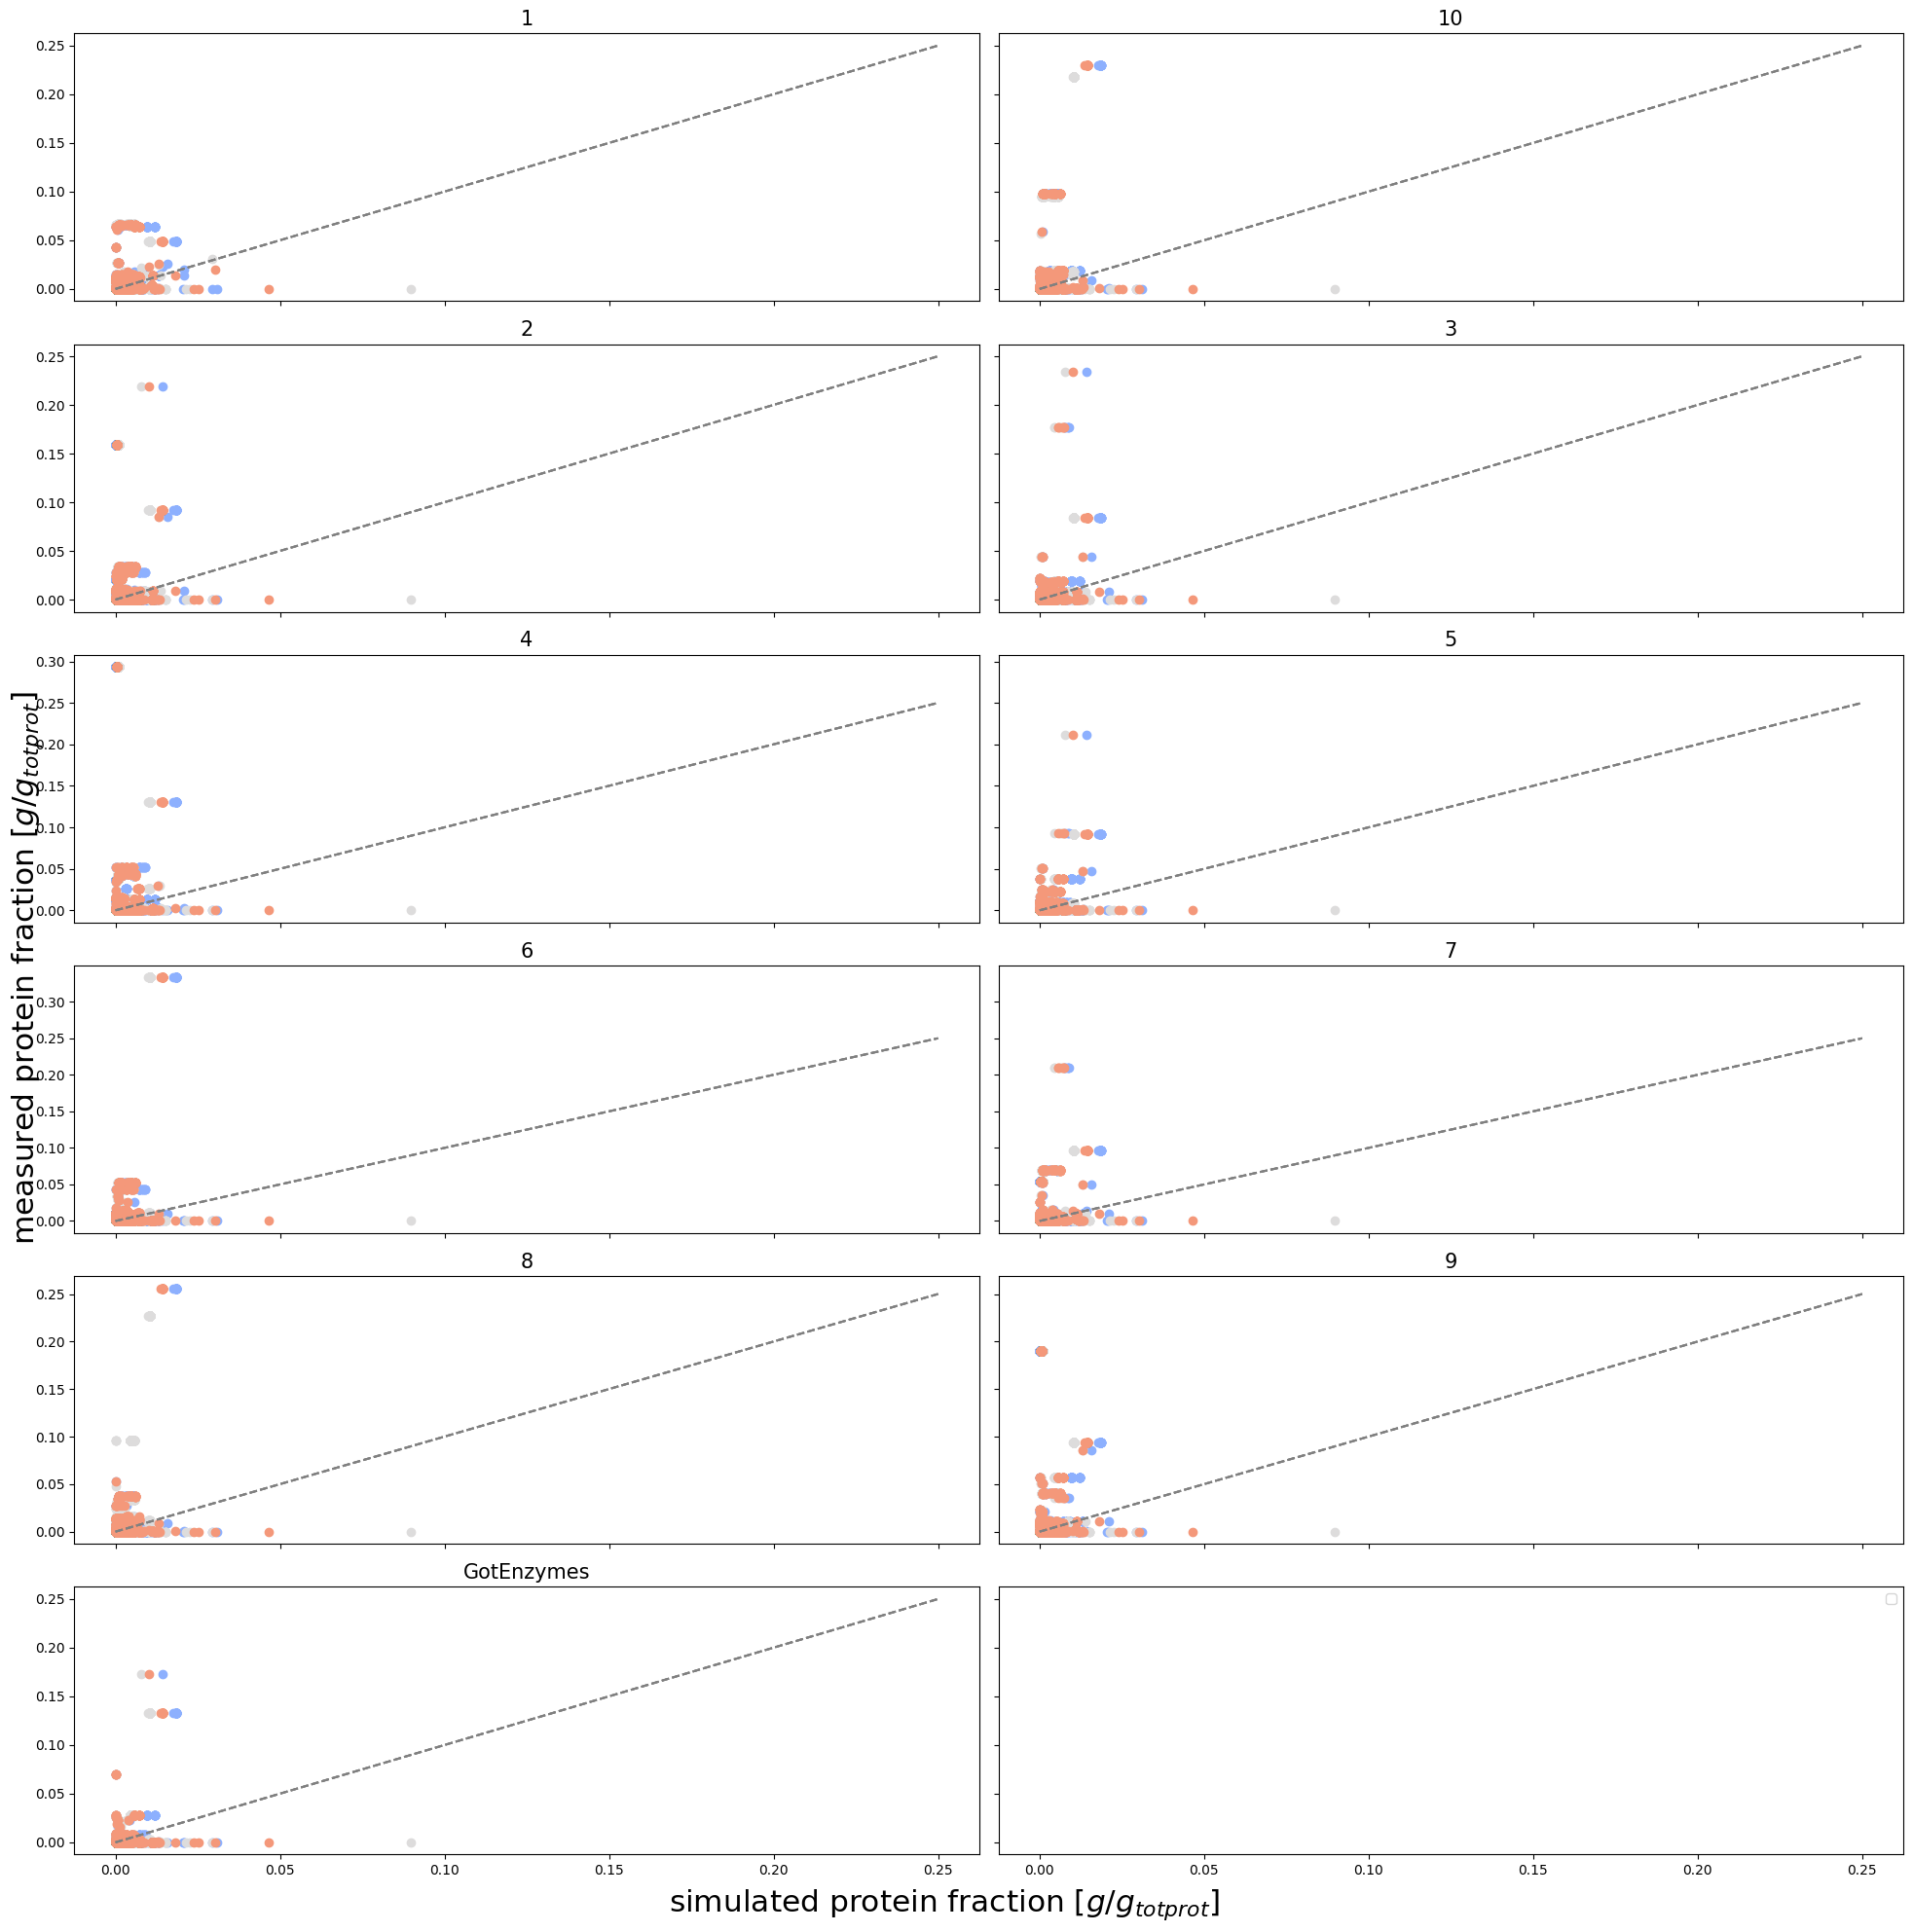

In [16]:
models = all_proteins_long.model.drop_duplicates()
model_colors = sns.color_palette("coolwarm", n_colors=len(models))
methods = all_proteins_long.method.drop_duplicates()
methods_colors = sns.color_palette("coolwarm", n_colors=len(methods))
cmap = dict(zip(methods, methods_colors))
fontsize=15

fig, axs = plt.subplots(nrows = int(np.ceil(len(models)/2)), 
                        ncols = 2, sharey='row', sharex='col', 
                        figsize = (20,20))
axs = axs.flatten()

for ax, group in zip(axs, all_proteins_long.groupby(['model'])):
    label, df = group[0], group[1]
    for method, method_df in df.groupby('method'):
        ax.plot([0,0.25], [0,0.25], linestyle = 'dashed', color='grey')
        ax.scatter(method_df['fraction'],method_df['normalized_fraction'], color = cmap[method])
        ax.set_title(label, fontsize = fontsize)
    

# Remove any unused subplots
for j in range(len(models)+1, len(axs)):
    fig.delaxes(axs[j])

fig.supxlabel(r'simulated protein fraction [$g/g_{totprot}$]', fontsize = fontsize*1.5)
fig.supylabel(r'measured protein fraction [$g/g_{totprot}$]', fontsize = fontsize*1.5)
plt.legend()

plt.tight_layout()
plt.show()

### 4.3 enzyme concentration distributions

In [ ]:
def create_joyplot(input_df,col_to_plot, col_to_hue,label_names: list[str], title,
                  result_fig_file:str=None):    
    # Set up the seaborn theme
    input_df['log'] = np.log10(input_df[col_to_plot])
    sns.set_theme(style="whitegrid")
    g = sns.FacetGrid(input_df, row=col_to_hue, hue=col_to_hue, aspect=15, height=0.6, palette="coolwarm")

    # Add KDE plots to the grid
    g.map(sns.kdeplot, 'log', fill=True, alpha=0.7, linewidth=1.5)

    # Add a white line to separate KDE plots for better visibility
    g.map(sns.kdeplot, 'log', color="white", linewidth=1)

    # Set y-labels using the provided label names
    for ax, label in zip(g.axes.flat, label_names):
        ax.text(0, 0, label, ha="right", va="bottom", fontsize=12, color="black", transform=ax.transAxes)

    # Format x-axis to display scientific notation (10^x)
    for ax in g.axes.flat:
        ticks = ax.get_xticks()
        ax.set_xticklabels([f"1e{round(i)}" for i in ticks], fontsize=10)

    # Customize appearance
    g.fig.subplots_adjust(hspace=-0.6)
    g.set_titles("")
    g.set(yticks=[], ylabel="")
    g.despine(bottom=True, left=True)

    # Add a title and x-axis label
#     plt.xscale('log')
    plt.title(title, fontsize=14, pad=20)
    plt.xlabel(r"Normalized peptide concentration [$g_{protein}/\sum g_{protein}$]", fontsize=12)

    # Tight layout for better spacing
    plt.tight_layout()

    # Save the plot
    if result_fig_file is not None:
        plt.savefig(result_fig_file, dpi=300)
    else:
        plt.show()

In [ ]:
all_proteins_per_configs = all_proteins_long.copy()
# Create a copy of the existing dataframe with modifications
measurement_df = all_proteins_per_configs[['enzyme_id', 'fraction', 'method', 'enzyme_type']].copy()
measurement_df['model'] = 'measurement'  # Assign 'measurement' to the model column
measurement_df.rename(columns={'fraction': 'normalized_fraction'}, inplace=True)  # Align column names

# Append the new rows to the original dataframe
all_proteins_per_configs = pd.concat([all_proteins_per_configs, measurement_df], ignore_index=True)
all_proteins_per_configs

In [ ]:
for experiment, peptide_df in all_proteins_per_configs.groupby('method'):
    create_joyplot(input_df=peptide_df,
                   col_to_plot = 'normalized_fraction', 
                   col_to_hue = 'model',
                   label_names=['measurements', 'GotEnzymes'] + [f'alternative {i}' for i in range(1,NUM_ALT_MODELS+1)],
                   title = experiment)
    max_expression_exp = peptide_df.normalized_fraction[peptide_df.model == 'measurement'].max()
    print(peptide_df[peptide_df.normalized_fraction >=max_expression_exp])

In [ ]:
create_joyplot(input_df=all_proteins_long,
                   col_to_plot = 'normalized_fraction', 
                   col_to_hue = 'model',
                   label_names=['measurements', 'GotEnzymes'] + [f'alternative {i}' for i in range(1,NUM_ALT_MODELS+1)],
                   title = '',
               result_fig_file = os.path.join('Results', '3_analysis', 'protein_concentration_joyplot.png')
              )
max_expression_exp = all_proteins_per_configs.normalized_fraction[all_proteins_per_configs.model == 'measurements'].max()
print(peptide_df[peptide_df.normalized_fraction >=max_expression_exp])
overexpressed_peptides = peptide_df[peptide_df.normalized_fraction >=max_expression_exp].enzyme_id.drop_duplicates()

#### Boxplots

In [ ]:
difference = {}
all_proteins_difference = all_proteins_long.copy()
all_proteins_difference['difference'] = all_proteins_difference['fraction']-all_proteins_difference['normalized_fraction']
all_proteins_difference

In [ ]:
fontsize = 10
fig, ax = plt.subplots(figsize=(12, 6))

# Boxplot or Violin Plot
sns.boxplot(x='model', y='difference', data=all_proteins_difference, ax=ax, showfliers=False)

# Adjust y-axis to focus on bulk data and add space for annotations
# ax.set_ylim([difference_df['difference'].quantile(0.05), difference_df['difference'].quantile(0.95)+3])

# Set labels and title
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=fontsize)
ax.set_xlabel('Model', fontsize=fontsize * 1.5)
ax.set_ylabel(r'Difference (exp - sim) p/$\text{g}_{p}$', fontsize=fontsize * 1.5)

plt.tight_layout()
plt.show()

## 5 COG analysis

In [ ]:
#match the cog classes to the protein concentrations
total_proteome_df_cog = all_proteins_long.merge(uniprot_df[['Entry', 'b_number']], 
                                                left_on = 'enzyme_id', 
                                                right_on = 'Entry')
total_proteome_df_cog = total_proteome_df_cog.merge(proteome_df_cog[['COG Name']], 
                                                left_on = 'b_number', 
                                                right_index=True)
#make sure there is only one COG associated with each row
total_proteome_df_cog['COG Name'] = total_proteome_df_cog['COG Name'].str.split(",")
total_proteome_df_cog = total_proteome_df_cog.explode('COG Name').reset_index(drop=True)
total_proteome_df_cog

In [ ]:
# total_proteome_df_cog[total_proteome_df_cog.Entry.isin([
#     overexpressed_peptides.to_list() + [
#         'P0A991',#isozyme of P0AB71
#         'P21177', #isozyme of P77399 #isozyme of P0A9B2 is not mapped to a gene annotation
#     ] 
# ])]
total_proteome_df_cog[total_proteome_df_cog.Entry=='P21177']
total_proteome_df_cog[total_proteome_df_cog.Entry=='P0AB71']



### 5.1 Plot abundances per COG

In [ ]:
total_proteome_df_grouped_cog = total_proteome_df_cog.groupby('COG Name')
col2label = {column: label for column, label in zip(
    cols, 
    ['Experiment', 'GotEnzymes']+[f'Alternative {i}' for i in range(1,NUM_ALT_MODELS+1)]
)
            }

fontsize = 15

model_colors = sns.color_palette("coolwarm", n_colors=len(col2label)-1)
cmap = dict(zip([name for name in cols if name != 'fraction'], model_colors))

n_rows = int(np.ceil(len(total_proteome_df_grouped_cog) / 3))
fig, axs = plt.subplots(n_rows, 3, figsize=(15, 5 * n_rows), sharex=True, sharey=False)

axs = axs.flatten()
i=0

for cog, prot_conc_df in total_proteome_df_grouped_cog:
    ax = axs[i]
    summary = prot_conc_df.groupby(['method'])[cols].sum()
    for col in cols:
        if col == 'fraction': 
            color = 'black'
            growth_rates = {'Batch':0.67,'mu_5':0.5, 'mu_35':0.35}
            label = col2label[col]
        else: 
            color = cmap[col]
            label = col2label[col]
            growth_rates = proteomics_results[label].drop_duplicates(['method', 'growth_rate']).set_index('method').to_dict()['growth_rate']
            if len(col.split('_')[-1]) == 1: label = 'alternative '+col2label[col]
            else: label = 'GotEnzymes'
        ax.scatter([growth_rates[method] for method in summary.index], summary[col], color= color, label = label)
        ax.set_title(cog, fontsize = fontsize)
        ax.set_xlabel('growth rate [h-1]', fontsize = fontsize)
        ax.set_ylabel('protein expression [g_p/g_totalp]', fontsize = fontsize)
        ax.set_yscale('log')
    i+=1

# Remove any unused subplots
for j in range(i, len(axs)):
    fig.delaxes(axs[j])
    
box = ax.get_position()
ax.set_position([box.x0, box.y0 + box.height * 0.1,
                 box.width, box.height * 0.9])
        
handles, labels = ax.get_legend_handles_labels()    
fig.legend(handles, labels, loc = 'lower center', bbox_to_anchor=(0.4, -0.05),ncols = 3, fontsize= fontsize)

    
plt.tight_layout()

## Adding protein concentrations as constraints

In [32]:
def constrain_pam_with_proteomics_measurements(pam, 
                                               measured_protein_df: pd.DataFrame):
    for i, row in measured_protein_df.iterrows():
        pam.enzyme_variables.get_by_id(row.enzyme_id).concentration = row.concentration
    return pam

def save_simulation_results(result_df: pd.DataFrame, 
                            all_results: list)-> list:
    for enzyme, conc in result_df.items():
        all_results.append({
            "Model": "Proteomics-Constrained",
            "Method": method,
            "Growth Rate": mu,
            "Enzyme": enzyme,
            "Concentration": conc
        })
    return all_results

In [ ]:
growth_rates = [0.67, 0.5, 0.35]
pam =  set_up_pam(ORI_PAM_KCAT_FILE, ECOLI_MODEL_FILE_PATH, sensitivity=False)
enzymes = [enz.id for enz in pam.enzyme_variables if enz._model is not None]
proteomic_constrained_results = []


for method, mu in zip(['Batch', 'mu_5', 'mu_35'], growth_rates):
    #get the measured concentration in mmol/gcdw
    exp_conc = proteome_glc_mmol[
        ['enzyme_id', method]
    ].rename(
        {method: 'concentration'},
        axis=1
    )
    
    pam_constrained = constrain_pam_with_proteomics_measurements(pam.copy(copy_with_pickle = True), 
                                               exp_conc)
    
    gotenzymes ={'GotEnzymes': get_results_from_simulations_fixed_mu(
        pamodel=pam_constrained,
        growth_rates = [mu],
        proteins_to_save = enzymes,
        method_ids = [method]
    )['proteins']}
    
    proteomic_constrained_results = save_simulation_results(gotenzymes,
                                                           proteomic_constrained_results)

    for file, label in zip(BEST_INDIV_RESULT_FILES,
                           [f'Alternative {i}' for i in range(1,len(PAM_KCAT_FILES)+1)]
                          ):
        print('\n')
        print(label)
        model = create_pamodel_from_diagnostics_file(
            file,
            pam_constrained.copy(copy_with_pickle=True)
        )
        
        enzymes = [enz.id for enz in model.enzyme_variables if enz._model is not None]
        alternative = {label: get_results_from_simulations_fixed_mu(pamodel=model,
                                                                          growth_rates = [mu],
                                                                          proteins_to_save = enzymes,
                                                                          method_ids = [method]
                                                                         )['proteins']}
        proteomic_constrained_results = save_simulation_results(alternative,
                                                           proteomic_constrained_results)
    
# Convert results to a dataframe
results_df = pd.DataFrame(proteomic_constrained_results)

# Display the first few rows
print(results_df.head())

# Optionally, save to a CSV file
results_df.to_csv("simulation_results.csv", index=False)
    

No enzyme information found for reaction: QUINDHyi
No enzyme information found for reaction: QUINDH
Setting up the proteome allocation model iML1515

Add total condition-dependent protein constraint
	Total protein concentration: 0.258 g/gDW

Add active protein sector

Add the following protein sector: TranslationalProteinSector

Add the following protein sector: UnusedEnzymeSector

Done with setting up the proteome allocation model iML1515

Running simulations with a growth rate of 0.67 1/h
The simulated growth rate is None 1/h with a substrate uptake rate of 0.0 mmol/g_cdw/h


Alternative 1


/home/samiralvdb/Software/anaconda3/envs/PAModelpy/lib/python3.9/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
/home/samiralvdb/Software/anaconda3/envs/PAModelpy/lib/python3.9/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
/home/samiralvdb/Software/anaconda3/envs/PAModelpy/lib/python3.9/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
/home/samiralvdb/Documents/3_Projects/7_MCA_analysis/PAModelpy/src/PAModelpy/PAModel.py:1533: UserWarning: The enzyme E2 does not exist in the model. The kcat can thus not be changed.
  warnings.warn(f'The enzyme {enzyme_id} does not exist in the model. The kcat can thus not be changed.')
/home/samiralvdb/Documents/3_Projects/7_MCA_analysis/PAModelpy/src/PAModelpy/PAModel.py:1533: UserWarnin

Running simulations with a growth rate of 0.67 1/h
The simulated growth rate is None 1/h with a substrate uptake rate of 0.0 mmol/g_cdw/h


Alternative 2


/home/samiralvdb/Software/anaconda3/envs/PAModelpy/lib/python3.9/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
/home/samiralvdb/Software/anaconda3/envs/PAModelpy/lib/python3.9/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
/home/samiralvdb/Software/anaconda3/envs/PAModelpy/lib/python3.9/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
